In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

In [2]:
X, y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1, noise=80, random_state=13)

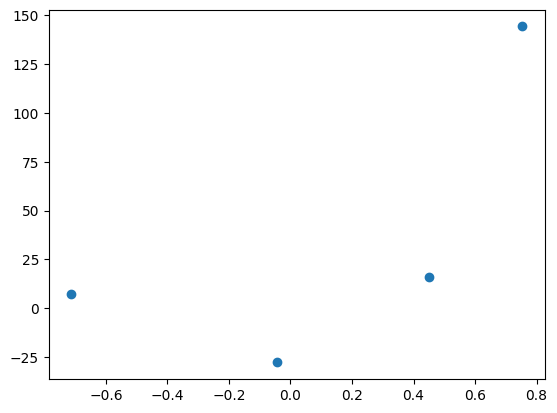

In [4]:
plt.scatter(X, y)

### First applying OLS to get original m and b

In [13]:
from sklearn.linear_model import LinearRegression
import numpy as np

In [7]:
lr = LinearRegression()

In [8]:
lr.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
print('Acutal m: ', lr.coef_)
print('Actual b:', lr.intercept_)
print('This b is our target b')

Acutal m:  [78.35063668]
Actual b: 26.15963284313262
This b is our target b


### Now applying gradient descent
<strong>Step 1: Starting at random b (b = 0)</strong> </br>
<strong>Step 2: Calculating slope at current b</strong>


In [37]:
b = 0
m = 78.35063668

slope = -2 * np.sum(y - m*X.ravel() - b)
slope

np.float64(-209.27706274458984)

<strong>step 3: Calculate new b</strong>

In [38]:
lr = 0.1

b = b - lr * slope # lr * slope is called size of the step

In [ ]:
b

np.float64(20.927706274458984)

<strong>Step 4: repate the iteration until reached original b</strong>

In [ ]:
for i in range(90):
    slope = -2 * np.sum(y - m*X.ravel() - b)
    b = b - lr * slope
b

np.float64(26.15963284307373)

## complete code

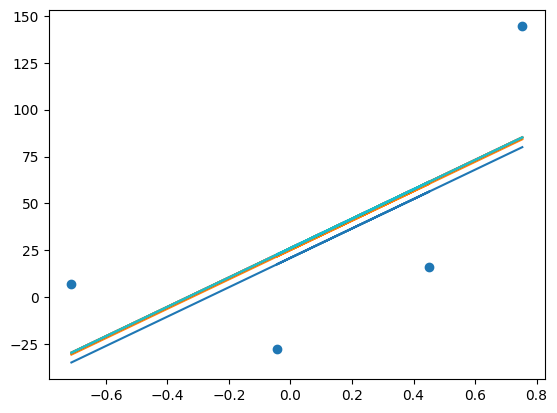

In [47]:
lr = 0.1
b = 0
m = 78.35063668

epochs = 10

for i in range(epochs):
    slope = -2 * np.sum(y - m*X.ravel() - b)
    b = b - lr * slope

    y_pred = m * X + b

    plt.plot(X, y_pred)

plt.scatter(X, y)